# Edit State - Human Feedback

### Review:
As we learnt earlier, adding breakpoint stops the graph from executing the node. 
- We can use this for
1. User Approval
2. Debugging
3. Editing oe updating/modifying the state 

### Goals
Now, let's show how to directly edit the graph state and insert human feedback.

In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"
                                         

In [2]:
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'

In [3]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [6]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

[{'type': 'text',
  'text': 'Today is **Tuesday, May 21, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbHBNbvqD+oCN2edfxo8fQb1slv21GvgSHmt+ShDRRjfgjkeZeNK9J5VGhAH7cI'}}]

### Build an agent with tool calling that uses breakpoint interruption for updating the state
- Add the breakpoint before the llm_model call


In [7]:
# define node fnctions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools)

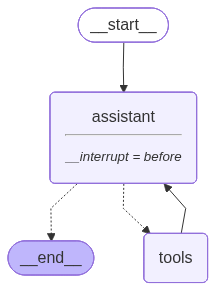

In [9]:
from IPython.display import Image, display
# set temprary memory
from langgraph.checkpoint.memory import MemorySaver

from langgraph.graph import MessagesState, START, StateGraph, END
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs using the tools.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
builder.add_edge("assistant", END)

memory = MemorySaver()
graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory) # interrupt is added before the LLm assistant node

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [12]:
# invoke graph
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread_config = {"configurable": {"thread_id": "2"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread_config, stream_mode="values"):
    print(event['messages'])

[HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='5d8f913f-69d8-437a-9cad-84aa98bfc67f')]


## Since breakpoint is applied befor the assistant node runs, we only see Humanmessage in the state

### Get State - state = graph.get_state(thread)

In [13]:
state = graph.get_state(thread_config)
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='5d8f913f-69d8-437a-9cad-84aa98bfc67f')]}, next=('assistant',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f144396-68f9-6d8a-8000-04d5c7875497'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-30T02:07:54.970868+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f144396-68f9-6d89-bfff-fb9f17166a84'}}, tasks=(PregelTask(id='40ece837-f182-075a-fb14-56d33aa510a0', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

## Update state directly using graph.update_state(thread_config,{'messages: "updated state"})

In [14]:
graph.update_state(
    thread_config,
    {"messages": [HumanMessage(content="No, actually multiply 3 and 3!")]},
)

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f144aeb-08fd-6565-8001-1bcef6291e0f'}}

## Check state again

-Notice MessagesState add_messages has appended the state messages key

In [17]:
state = graph.get_state(thread_config).values
state

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='5d8f913f-69d8-437a-9cad-84aa98bfc67f'),
  HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='7d501771-bd79-4d73-9fe4-ebd471dc2bf8')]}

## Continue runnning the agent by passing None as messages

In [18]:
# Run the graph until the first interruption
for event in graph.stream(None, thread_config, stream_mode="values"):
    event['messages'][-1].pretty_print()

[HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='5d8f913f-69d8-437a-9cad-84aa98bfc67f'), HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='7d501771-bd79-4d73-9fe4-ebd471dc2bf8')]
[HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='5d8f913f-69d8-437a-9cad-84aa98bfc67f'), HumanMessage(content='No, actually multiply 3 and 3!', additional_kwargs={}, response_metadata={}, id='7d501771-bd79-4d73-9fe4-ebd471dc2bf8'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 3, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'b0c2f257-51ff-4821-85dc-34f9f0169e0b': 'EjQKMgEMOdbH5WxClmv+7PfRDPWJ8OoCMvh3CQOmRD6rsrl1pyD5IG2FvW8uEyQIkuwr1/Ml'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ddf89-25c6-7

### Since breakpoint is at the assistant node, graph execution is halted for user approval
- Pass None again to continue

In [19]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

9
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result of multiplying 3 and 3 is 9.', 'extras': {'signature': 'EjQKMgEMOdbHcR/oxFtpVKjCEdGdvAS9cFVB99SglFYxtdXVpZiJ6Ary0Tmm0wNpEXX6kS7Z'}}]


## Human Feedback

Since we learnt to edit the state, Lets add the node to perform Human feedback

### Human_Feedback Node:
1. Allows the user to add feedback directly to state.
2. We specify the breakpoint using interrupt_before our human_feedback node.
3. We set up a checkpointer to save the state of the graph up until this node.

### Goal:  Build a graph with feedback node

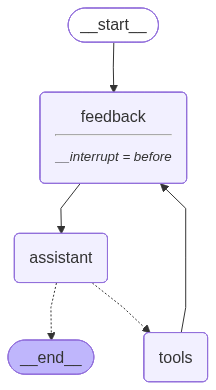

In [23]:
# define the node functions

sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs using the tools.")


def feed_back(state:MessagesState):
    pass

def assistant(state:MessagesState):
    return {'messages': [llm_with_tools.invoke([sys_msg] + state['messages'])]}

# build a graph
builder = StateGraph(MessagesState)

# add nodes and edges
builder.add_node('assistant', assistant)
builder.add_node('tools', ToolNode(tools))
builder.add_node('feedback', feed_back)

builder.set_entry_point('feedback')
builder.add_edge('feedback', 'assistant')
builder.add_conditional_edges('assistant' , tools_condition)
builder.add_edge('tools', 'feedback')
builder.add_edge('assistant', END)

memory = MemorySaver()
# compile
graph = builder.compile(checkpointer=memory , interrupt_before=["feedback"])

graph

## Update

- Get feedback
- update state
- use tools

In [51]:
# invoke tools
inp_msg = {'messages': [HumanMessage(content="multiply 10 by 50 and add 20")]}

thread_config = {"configurable": {'thread_id': "8"}}

for chunk in graph.stream(inp_msg , thread_config , stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='multiply 10 by 50 and add 20', additional_kwargs={}, response_metadata={}, id='6b930ec3-fa79-4168-bc03-6d1af9b82ce9')]}


### Add a human input to the feedback state

- apply the feedbackt to a specified node
- default is node with breakpoint

In [52]:
user_msg = input("How would you like to update the state?: ")

# use update
graph.update_state(thread_config, {'messages': user_msg } , as_node="feedback") # set to as node or if node is not specified, set to node with beakpoint
                                   
# Continue the graph execution
for event in graph.stream(None, thread_config, stream_mode="values"):
    event["messages"][-1].pretty_print()

How would you like to update the state?:  continue..


================================ Human Message =================================

continue..
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (c0fc6cdf-ac33-4a01-8a66-9dfa0ac73dcb)
 Call ID: c0fc6cdf-ac33-4a01-8a66-9dfa0ac73dcb
  Args:
    a: 10
    b: 50
================================= Tool Message =================================
Name: multiply

500


### Stops again for feedback due to breakpoint aft tool node
re-run the graph without feedback or an update

In [53]:
for event in graph.stream(None, thread_config, stream_mode="values"):
    event["messages"][-1].pretty_print()


================================= Tool Message =================================
Name: multiply

500
================================== Ai Message ==================================

[]
Tool Calls:
  add (54031f3d-6e71-487f-ba43-b751e4ecfc7d)
 Call ID: 54031f3d-6e71-487f-ba43-b751e4ecfc7d
  Args:
    a: 500
    b: 20
================================= Tool Message =================================
Name: add

520


## Stopped for another feedback
Provide feedback

In [55]:
user_msg = input("How would you like to update the state?: ")

# use update
graph.update_state(thread_config, {'messages': user_msg } , as_node="feedback") # set to as node or if node is not specified, set to node with beakpoint
                                   
# Continue the graph execution
for event in graph.stream(None, thread_config, stream_mode="values"):
    event["messages"][-1].pretty_print()

How would you like to update the state?:  add 50


================================ Human Message =================================

add 50
================================== Ai Message ==================================

[]
Tool Calls:
  add (a8793749-a702-40ff-903d-eca2b803b686)
 Call ID: a8793749-a702-40ff-903d-eca2b803b686
  Args:
    a: 520
    b: 50
================================= Tool Message =================================
Name: add

570


## stops for feedback again after the tool use
run without feedback

In [56]:
# Continue the graph execution
for event in graph.stream(None, thread_config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: add

570
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result is 570.', 'extras': {'signature': 'EjQKMgEMOdbHN/XDy6XbRo0OYs+XK+Ll2uSwNo4d0mmhyCPDcKLhxUjG+zeLnCKCNQmh5yOo'}}]


### Final Answer is from the LLM node